In [1]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import sys
import matplotlib.pyplot as plt
import folium
from collections import Counter
import matplotlib.patches as mpatches
import contextily as ctx
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from shapely.geometry import box
import matplotlib.lines as mlines


# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
import functions_local as inv_local 
# import functions_national as inv_natl
import functions_inference as infr
import functions_point_to_ftpt_general_bounding as inv_natl

In [2]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]


In [3]:
# Target Directory 
directory = './Inventory_Outputs/Synthesized_Local/'

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_attribution = directory + 'FootprintAttribution/'
dir_intermediate = dir_attribution + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

## **Load Baseline Geometry (Footprints), Study Boundaries (Census), and Bounding Geometry (Parcels)**

In [ ]:
### LOAD FOOTPRINTS

# Select Footprint Source
footprint_path = './Input_Data/ProcessedFootprints/Hayward_Footprints.json'
footprints = gpd.read_file(footprint_path)
footprints.to_crs(crs_main, inplace = True)
footprints['FootprintID'] = footprints['FootprintID'].astype('Int64')

### DESCRIPTION ###
# Compute square footage to be used for "not full footprint" designation during merge process
# If most footprints have FootprintHeight available (in feet), set estimate_stories = True
# If most footprints do not have FootprintHeight available, using height to designate if 
# a footprint is not full may cause bias, and it is better to just use FootprintArea (set estimate_stories = False)

# Assign total square footage used for prioritizing attribution of points to footprints using "not full footprint"
estimate_stories = False
footprints = inv_natl.estimate_ftpt_size_for_merge(footprints.copy(),estimate_stories)

In [ ]:
## LOAD STUDY BOUNDARIES 

# Load Census blocks and tracts (generated in preprocessing file)
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')

# Census 2020 GEOID field name
geoid = 'GEOID10'  

In [8]:
## LOAD BOUNDING GEOMETRY (PARCELS)

# Load parcel data and Census blocks 
parcels = gpd.read_file('./Input_Data/Local/Hayward_Parcels.geojson')
parcels = parcels.to_crs(epsg=crs_main)

In [9]:
parcels

,APN_PQ,APN_ACA,OBJECTID,APN_GIS,APN_BK_PG,OWNERCENSORED,P_HouseNum,P_Prefix,P_Pre_Type,P_Street_Name,...,P_State,P_Zipcode,P_AREA,P_ST_ADDRESS,M_ST_ADDRESS,M_CITY,M_STATE,M_ZIP_FULL,TAXRATEAREA,geometry
0,453-0085-092-00,453-85-92,1,453008509200,4530085,WU SHUAI,725,None,None,AUBURN,...,CA,94544,779.348427,725 AUBURN PL 102,534 HEMLOCK AVE,MILLBRAE,CA,94030,25030,"POLYGON ((581921.788 4165561.774, 581923.044 4..."
1,453-0085-091-00,453-85-91,2,453008509100,4530085,SOUZA RUBEN & VICENTE ETAL,725,None,None,AUBURN,...,CA,94544,692.894548,725 AUBURN PL 202,725 AUBURN PL 202,HAYWARD,CA,94544,25030,"POLYGON ((581926.906 4165562.288, 581928.22 41..."
2,453-0085-090-00,453-85-90,3,453008509000,4530085,DINH TRUNG Q & NGUYEN THUY X,725,None,None,AUBURN,...,CA,94544,744.265893,725 AUBURN PL 201,725 AUBURN PL 201,HAYWARD,CA,94544,25030,"POLYGON ((581923.044 4165547.821, 581921.788 4..."
3,444-0036-086-00,444-36-86,4,444003608600,4440036,LOPEZARGUELLO JORGE A & ICABALZETA GISELE D,24843,None,None,ONEIL,...,CA,94544,4009.031189,24843 ONEIL AVE 2,P O BOX 56365,HAYWARD,CA,94545,25223,"POLYGON ((581472.036 4168519.999, 581468.28 41..."
4,444-0036-087-00,444-36-87,5,444003608700,4440036,HUYNH CHRISTINA H TR,24851,None,None,ORANGETREE,...,CA,94544,1436.830435,24851 ORANGETREE PL 3,24851 ORANGETREE PL 3,HAYWARD,CA,94544,25223,"POLYGON ((581440.915 4168507.729, 581444.416 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68368,452-0056-013-00,452-56-13,68369,452005601300,4520056,REEVES RUTH H TR & TKS PROPERTIES INC,26869,None,None,MISSION,...,CA,94544,99240.463458,26869 MISSION BLVD,1855 BENICIA RD,VALLEJO,CA,94591,25224,"POLYGON ((582600.141 4166699.258, 582526.43 41..."
68369,452-0056-014-00,452-56-14,68370,452005601400,4520056,CORAL GARDENS APARTMENTS LLC,605,None,None,SORENSON,...,CA,94544,93309.597623,605 SORENSON RD,PO BOX 308,SAN RAMON,CA,94583,25224,"POLYGON ((582523.021 4166916.07, 582520.436 41..."
68370,452-0056-015-00,452-56-15,68371,452005601500,4520056,CORAL GARDENS APARTMENTS LLC,26825,None,None,COLETTE,...,CA,94544,18641.474503,26825 COLETTE ST,PO BOX 308,SAN RAMON,CA,94583,25224,"POLYGON ((582567.413 4166903.232, 582543.195 4..."
68371,452-0056-016-00,452-56-16,68372,452005601600,4520056,E P & G MISSION PLAZA LLC,26953,None,None,MISSION,...,CA,94544,273376.282266,26953 MISSION BLVD,4020 MOORPARK AVE 218,SAN JOSE,CA,95117,25224,"POLYGON ((582697.709 4166884.368, 582635.957 4..."


## **Preprocess Address Data**

In [6]:
# Load address data downloaded from Hayward GIS
points = gpd.read_file('./Input_Data/Local/Hayward_Addresses.geojson')
points = points.to_crs(epsg=crs_main)

In [7]:
### CLEAN ADDRESS DATA AND PREPARE FOR MERGE WITH SCRAPED DATA ###

# Remove exact duplicates from hayward res data 
print('All Hayward Address Points:',len(points))
points = points.drop_duplicates() # Remove exact duplicates
print('After exact duplicates:',len(points))

All Hayward Address Points: 82047
After exact duplicates: 82047


### **Trim to study boundaries**

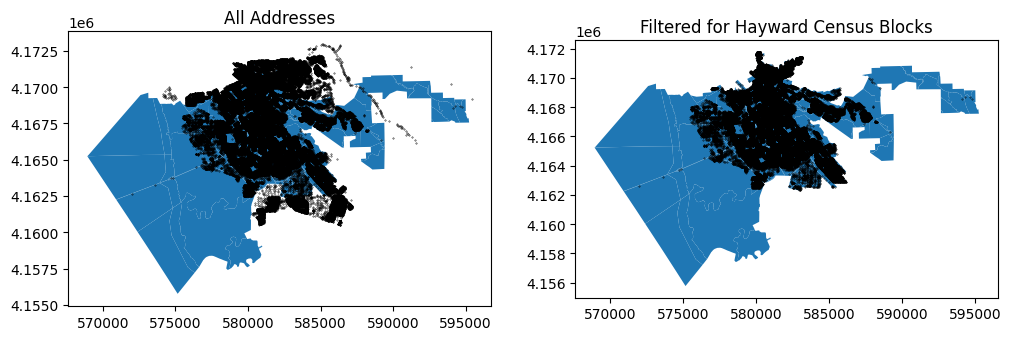

In [8]:
# Trim to study boundaries 

# Plot
fig, ax = plt.subplots(1,2, figsize = (12, 12))
hayward_blocks.plot(ax=ax[0])
points.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('All Addresses')

# Assign block to addresses
points_copy = points.copy()
points_copy = points_copy.sjoin(hayward_blocks, how='left')
points.loc[:, 'CensusBlock'] = points_copy[geoid].values

# Assign tract to addresses
points_copy = points.copy()
points_copy = points_copy.sjoin(hayward_tracts, how='left')
points.loc[:, 'CensusTract'] = points_copy[geoid].values

# Drop rows that are not in blocks of interest (Hayward)
points = points[~points['CensusBlock'].isna()].copy()

# Plot to check 
hayward_blocks.plot(ax=ax[1])
points.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Filtered for Hayward Census Blocks')
plt.show()

### **Map to a common ontology and drop relevant points**

In [9]:
# Map building feature codes to Hazus occupancy class values 

### CONVERT TO NSI ###

# NAICS CODES https://www.census.gov/naics/?input=22&chart=2022&details=221310

# NAICS Codes are based on business classification - not the same as building classification 

# Define map between Address Point Feature Code and NSI 
fc_map = {
    np.nan : None,
    'Single-Family Dwelling' : 'RES1', 
    'Single-Family Residential' : 'RES1',
    'Duplex' : 'RES3A',
    'Single Family Residence with addressed ADU': 'RES1',
    'Single-Family Dwelling Accessory Suite': 'RES1_ADU',
    'Multi-Family Lot, Single Family Residence': 'RES1',
    'Multi-Family Dwelling, Apartment':'RES3',
    'Triplex':'RES3B',
    'Multi-Family Dwelling':'RES3',
    'Multi-Family Residential':'RES3',
    'Multi-Family':'RES3',
    'Multi-Family Dwelling, Condominium':'RES3',
    'Fourplex':'RES3B',
    'Multi-Family Dwelling, Townhouse':'RES3',
    'Mobile Home Park': 'RES2',
    'Mobile / Modular / Manufactured Home': 'RES2',
    'Single Family Residence, Duet' : 'RES3A',
    'Institutional Residence / Dorm / Barracks': 'RES5',
    'Single Family Residence with non-addressed ADU':'RES3A',  
    'Single Family Residential - Converted from Only ADU' : 'RES1',
    'Airport Hangar' : 'COM4', # NAICS 488119 checked using Hazus document
    'Bank' : 'COM5',
    'Banking or Finance Facility' : 'COM5',
    'Building General' : 'UNK',
    'Building Shell' : 'UNK',
    'Business Park Office' : 'COM4',
    'Cellular Site' : 'NOTBLDG', #### DIVERGE: NAICS 237130 (Power and Communication Lines) is classified as IND6, which is why there may be buildings in the roads. I chose to leave this as 'NOTBLDG' in this case 
    'Cemetery' : 'NOTBLDG', #### DIVERGE: NAICS 812220 (Cemetaries and Crematories) classified as COM4. I chose to leave this as 'NOTBLDG' in this case 
    'Clubhouse / Community Building' : 'COM8',
    'College / University' : 'EDU2',
    'Commercial or Retail Facility' : 'COM1', 
    'Common Area' : 'NOTBLDG', 
    'Communication Tower' : 'NOTBLDG', # DIVERGE: NAICS 237130 (Power and Communication Lines) is classified as IND6, which is why there may be buildings in the roads. I chose to leave this as 'NOTBLDG' in this case 
    'Cooperative' : 'RES3', # There could be housing or business cooperatives, but assuming here it is a housing cooperative
    'County Government Facility' : 'GOV1',
    'Dairy' : 'AGR1',
    'Day Care Facility' : 'COM3', # NAICS 624410 checked using Hazus document 
    'Education Facility' : 'EDU1',
    'Electric Vehicle Charging Station' : 'NOTBLDG', # Didn't seem to have a clear NAICS code 
    'Electrical Meter' : 'NOTBLDG', # DIVERGE: NAICS 221122 (Electrical Power Distribution) is COM4, NAICS 334515 (Instrument Manufacturing for Electrical Signals) is IND2. I chose to leave thie as 'NOTBLDG' in this case
    'Energy Facility' : 'IND1',  # Depending on type of energy, NAICS codes designated as IND1 or IND2. Here, using IND1 
    'Fire Station / EMS Station' : 'GOV2', 
    'Fitness Center' : 'COM8', 
    'Gas Station': 'COM1', # NAICS 447110 checked using Hazus document
    'Gate' : 'NOTBLDG', 
    'Golf Course' : 'NOTBLDG', # DIVERGE: NAICS 713910 (Golf Courses and Country Clubs) classified as COM8. I chose to leave as 'NOTBLDG' in this case 
    'Government or Military Facility' : 'GOV1',
    'Greenhouse / Nursery' : 'AGR1',
    'Grocery Store': 'COM1',
    'Health or Medical Facility' : 'COM7',
    'Hospital / Medical Center' : 'COM6',
    'Hotel / Motel' : 'RES4',
    'House of Worship': 'REL1',
    'Industrial Business Park' : 'IND', # Insufficient specificity for more detailed designation 
    'Industrial Condominium': 'IND', # Insufficient specificity for more detailed designation 
    'Industrial Facility' : 'IND', # Insufficient specificity for more detailed designation 
    'Information or Communication Facility' : 'IND6', # NAICS 237130 checked using Hazus document 
    'Irrigation Controller' : 'COM4', # NAICS 221310 (Water Supply and Irrigation Systems) checked using Hazus document 
    'Library' :'GOV1', # DIVERGE: NAICS 519120 (Libraries and Archives) listed under COM4, but I thought it was more appropriate as a governemntal building 
    'Light Rail Station' : 'COM4', # 485112 (Commeter Rail Systems) checked using Hazus document 
    'Motor Vehicle Dealer' : 'COM1',
    'Motor Vehicle Repair' : 'COM3',
    'Municipal Government Facility' : 'GOV1',
    'Nursing Home / Long Term Care' : 'RES6',
    'Park' : 'NOTBLDG',
    'Parking Lot' : 'NOTBLDG', # DIVERGE: NAICS 812930 (Parking Lots and Garages) classified as COM3. I chose to leave as 'NOTBLDG' in this case
    'Post Office' : 'GOV1',
    'Public Attraction or Landmark Building' : 'GOV1',
    'Street Light':'NOTBLDG',
    'Public Pool' : 'NOTBLDG', # DIVERGE: NAICS 713940 (Fitness and recreational Sports Centers) listed under COM8. I chose to leave as 'NOTBLDG' in this case
    'Pump' : 'NOTBLDG', # DIVERGE: NAICS 333911 (Pump and Pumping Equipment Manufacturing) under IND1 and 221310 (Water Supply) under COM4. I chose to leave as 'NOTBLDG' in this case
    'Railroad Facility' : 'COM4',  # 485112 (Commeter Rail Systems) checked using Hazus document 
    'Railroad Maintenance / Fuel Facility' : 'COM4', # NAICS 488210 checked using Hazus document 
    'Recycling Facility' : 'COM4', # NAICS 562920 checked using Hazus document 
    'Restaurant / Eating Establishment' : 'COM1',
    'Rural / Open Space' : 'NOTBLDG',
    'School: Elementary' : 'EDU1',
    'Shopping Mall / Complex' : 'COM1',
    'State Government Facility' : 'GOV1',
    'Substation' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Telecom Utility Box' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Telephone Facility' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Traffic Signal' : 'NOTBLDG',
    'Transportation Facility' : 'COM4', # NAICS 488490 (Support Activiies for Road Transportation) checked using Hazus document 
    'Trucking Firm' : 'COM2', # NAICS 484110 (General Freight Trucking, Local) and 484121 (General Freight Trucking, Long-Distance) checked using Hazus document 
    'Vacant Land' : 'NOTBLDG',
    'Warehouse' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Warehouse (Retail / Wholesale)' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Water Meter' : 'NOTBLDG',
    'Water Tank' : 'NOTBLDG',
    'Water Treatment Facility' : 'GOV1', # DIVERGE: NAICS 221320 (Sewage Treatment Facilities) listed as COM4, may be more appropriate as GOV1? 
    'Emergency Response or Law Enforcement Facility':'GOV2',
    'Electric Facility': 'NOTBLDG',
    'Rehabilitation Center':'COM7',
    'Agriculture or Livestock Structure':'AGR1',
    'American Red Cross Facility':'COM7',
    'Private Water Supply Well': 'NOTBLDG',
    'Water Pumping Station':'NOTBLDG',
    'Mine':'NOTBLDG',
    'Fire Pump':'NOTBLDG',
    'Water Supply or Treatment Facility':'GOV1'
}


### CONVERT ADDRESS FEATURE CODE TO NSI ###
points['FC_Hazus'] = points['FeatureCode'].apply(inv_local.map_values, occ_map = fc_map)

In [10]:
# Drop Addresses that are not Buildings (NOTBLDG)
print(len(points[points['FC_Hazus']=='NOTBLDG']), 'points labeled NOTBLDG')
points = points[points['FC_Hazus']!='NOTBLDG']
print(len(points), 'points for processing')

848 points labeled NOTBLDG
62320 points for processing


### **Create and Assign Columns for Point to Footprint Attribution**

In [11]:
## Drop any columns that do not need to be retained in inventory development process
# Use points.columns to view current columns

### DROP COLUMNS THAT DO NOT NEED TO BE REATINED THROUGHOUT INVENTORY GENERATION ###
points['Zone'].unique()
columns_to_drop = ['APN_GIS','Status','Affordability_Level','Affordable','Pre_Type','Zone','SitusAddress','OBJECTID',
                   'HouseNum', 'Prefix', 'Pre_Type','Street_Name', 'Street_Type', 'Suffix_Dir', 'House_Unit', 'City',
                    'State', 'Zipcode', 'Zone', 'FullAddress', 'AddrUnit_Type','SubtypeField']
points = points.drop(columns=columns_to_drop)

##### CREATE TRACKING COLUMNS TO BE USED IN FOOTPRINT MERGE #####
points['POINT_ID'] = range(len(points)) # This is an ID number that is used throughout the script to refer to each row
points['POINT_FootprintID'] = pd.Series([pd.NA] * len(points), dtype='Int64') #None # This is the FootprintID that will be paired witht the point data throughout
points['DistanceToFtpt'] = None 
points['ClosestFtpt_ID'] = None
points['POINT_ID_List'] = points['POINT_ID'] # This tracks the ID numbers associated with that row 
points['POINT_NumPoints'] = 1 # This tracks the number of points consolidated into the single row 
points['POINT_MergeFlag'] = 0 # This tracks at what stage the point and footprint are merged


##### CREATE ADDITIONAL COLUMNS TO BE USED IN FOOTPRINT MERGE #####
points['POINT_DropFlag'] = 0 # This indicates whether a row should be dropped from the final inventory. 1 indicates yes, 0 indicates no 
points['POINT_DropNote'] = "" # Space for notes on the reason data points are dropped 
points['POINT_Source'] = 'AddressPoints' # This tracks the original data source for each row 
points['POINT_DataUpdate'] = "" # Space for notes on steps throughout update 

# Needed only for NSI 
# address_hayward['NSI_OC_Update'] = None # This will contain updated Occupancy Class values throughout merge

In [13]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'CensusBlock', 'CensusTract', 'POINT_DropFlag', 'POINT_DropNote','POINT_ID',
            'POINT_FootprintID', 'DistanceToFtpt', 'ClosestFtpt_ID', 'POINT_MergeFlag','POINT_DataUpdate']
sum_columns = ['POINT_NumPoints']
list_columns = ['Address_ID', 'FeatureCode', 'FC_Hazus', 'APN_PQ','LonTxt_X', 'LatTxt_Y','POINT_Source','POINT_ID_List']

# Print unassigned columns 
counter = 0
for col in points.columns: 
    if (col not in sum_columns) and (col not in list_columns) and (col not in excluded): 
        print(col, 'is unassigned -- please assign')
        counter += 1
if counter == 0: 
    print('No Unassigned Columns')
    

No Unassigned Columns


In [14]:
# Save
inv_local.gdf_to_json(points, dir_intermediate + 'Address_for_Merge.json')

JSON File Saved


## **Attribute Points to Footprints**

In [15]:
##### LOAD PREPROCESSED DATA FOR MERGE #####
points = inv_natl.json_to_gdf(dir_intermediate + 'Address_for_Merge.json', crs_main)

##### DISPLAY NUMBER OF POINTS #####
points_length = len(points) # Used for tracking purposes 
print('NSI:', len(points))
print('Footprints:', len(footprints))

NSI: 62320
Footprints: 38300


### **MergeFlag1 - Address Cases with 1 Footprint and 1 Point**

In [16]:
##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 

##### RUN FUNCTION TO MERGE CASES WITH ONE POINT WITHIN ONE FOOTPRINT #####
points0, map = inv_natl.merge_intersecting(points0, footprints, crs_plot)

# Plot overlapping footprints if found 
if isinstance(map, str):
    print(map)
else: 
    display(map)

# # Update MergeFlag99 for footprints that are larger than their designated occupancy type -- MTL MAKE NOTE ON WHY REMOVED (OR FLAG OR SOMETHING )
# points0 = inv_natl.update_mergeflag99(points0, footprints, mergeflag = 1)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = inv_natl.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
inv_natl.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag1.json')


Points within Footprints: 55649
Unique points within Footprints (one point per footprint): 26620
Data with Associated Footprints (should match row above): 26620
Passed Check: No overlapping footprints found
Passed Check: No duplicates found
JSON File Saved


In [18]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag1.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

### **MergeFlag2 - Address Cases with 1 Footprint and Multiple Points**

In [19]:
##### LOAD DATA #####
points = inv_natl.json_to_gdf(dir_intermediate + 'MergeFlag1.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
points = inv_natl.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 


#### RUN FUNCTION TO MERGE CASES WITH MULTIPLE POINTS WITHIN ONE FOOTPRINT #####
# Set flag to print odd occupancy pairings, including (RES + IND), (RES + GOV), and (EDU + IND) - does not change function outputs, only displays 
print_odd_occupancy_pairings = False
use_size_limit = False
use_nsi_occupancy_merge = False
points0 = inv_natl.address_overlapping_points(points0.copy(), footprints.copy(), list_columns, sum_columns, manually_assigned_occupancy,use_size_limit, use_nsi_occupancy_merge, print_odd_occupancy_pairings, crs_plot)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = inv_natl.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
inv_natl.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag2.json')

Number of Points Remaining: 35700
Number of Footprints Remaining: 11680
Number of Points within Footprint Polygons: 29050
Number of Footprints with Multiple Points (Looping Through These Now): 4294
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [ ]:
# # ### UNCOMMENT CODE TO PLOT STATIC MAP WITH FOOTPRINTS AND POINTS
# points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))
# fig, ax = plt.subplots(figsize=(30,30))
# footprints.plot(ax=ax, color = 'gray', alpha = 0.3)
# remaining.plot(ax=ax, markersize = 1)
# plt.show()

In [20]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in points[points['NSI_FootprintID'].isna()].copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

### **MergeFlag310 - Merge Points within 10m of a Footprint**

In [21]:
# Load data 
points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag2.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
points = inv_natl.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
points0 = points[points['POINT_DropFlag']!=1].copy() # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1].copy() # Dropped - these should not be used in merge 


##### CONDUCT MERGE #####

# Get list of census blocks
CB_list = hayward_blocks[geoid].unique() # MTL changed geoid 

# Merge data using function 
points0 = inv_natl.distance_limit_merge(CB_list, points0.copy(), footprints, geoid, manually_assigned_occupancy, list_columns, sum_columns, hayward_blocks, crs_plot,
                            distance_limit = 10, 
                            use_surrounding_blocks = True, # Footprints in surrounding census blocks will be considered for each NSI point
                            use_partial_footprints = False, # Footprints with MergeFlag = 99 will be considered for each NSI point (once empty footprints in distance limit have been exhausted)
                            use_full_footprints = True, # Full footprints will be considered for each NSI point (once empty and partial footprints in distance limit have been exhausted)
                            merge_flag = 310, 
                            use_size_limit = False,
                            use_nsi_occupancy_merge = False,
                            print_odd_occupancy_pairings = False) # If True, some occupancy class pairs will be printed out if they are merged into same footprint to manually check 


##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
points = inv_natl.recombine_dropped_data(points0, points1, points_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
inv_natl.check_post_merge_duplicates(points.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag310.json')


Number of Points Remaining: 6650
Number of Footprints Remaining: 7386
Processing 1488 Census Blocks
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [22]:
# # ### UNCOMMENT CODE TO PLOT STATIC MAP WITH FOOTPRINTS AND POINTS
# points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))
# fig, ax = plt.subplots(figsize=(30,30))
# footprints.plot(ax=ax, color = 'gray', alpha = 0.3)
# remaining.plot(ax=ax, markersize = 1)
# plt.show()

In [47]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=0) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue',
#                         popup = row['FeatureCode']).add_to(m)

# display(m)

### **MergeFlag3100 - Merge Points within 100m of a Footprint**


Recommended if using very messy data where points may appear farther from footprints (likely not the case in SF, do not recommend using this)

In [23]:
# # Load data 
# points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)


# ##################################################################################################################################

# ############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

# ##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
# manually_assigned_occupancy_data = {
#     "FootprintID":[], # Put FootprintID values in this list
#     "POINT_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
#                              # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
# manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

# ##### MANUALLY DROP NSI POINTS HERE #####
# ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
# points = inv_natl.drop_ids(points, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

# ##################################################################################################################################


# ##### SPLIT DATA BASED ON DROP_FLAG #####
# points0 = points[points['POINT_DropFlag']!=1].copy() # Not dropped - these should be used in merge
# points1 = points[points['POINT_DropFlag']==1].copy() # Dropped - these should not be used in merge 


# ##### CONDUCT MERGE #####

# # Get list of census blocks
# CB_list = hayward_blocks[geoid].unique() # MTL changed geoid 

# # Merge data using function 
# points0 = inv_natl.distance_limit_merge(CB_list, points0.copy(), footprints, geoid, manually_assigned_occupancy, list_columns, sum_columns, hayward_blocks, crs_plot,
#                             distance_limit = 100, 
#                             use_surrounding_blocks = False, # Footprints in surrounding census blocks will be considered for each NSI point
#                             use_partial_footprints = False, # Footprints with MergeFlag = 99 will be considered for each NSI point (once empty footprints in distance limit have been exhausted)
#                             use_full_footprints = True, # Full footprints will be considered for each NSI point (once empty and partial footprints in distance limit have been exhausted)
#                             merge_flag = 3100, 
#                             use_size_limit = False,
#                             use_nsi_occupancy_merge = False,
#                             print_odd_occupancy_pairings = False) # If True, some occupancy class pairs will be printed out if they are merged into same footprint to manually check 


# ##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
# points = inv_natl.recombine_dropped_data(points0, points1, points_length)

# ##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
# points['POINT_FootprintID'] = points['POINT_FootprintID'].astype('Int64')
# inv_natl.check_post_merge_duplicates(points.copy())

# ##### SAVE JSON FILE #####
# inv_natl.gdf_to_json(points.copy(), dir_intermediate + 'MergeFlag3100.json')


In [24]:
# # ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
# points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag3100.json', crs_main)
# remaining = points[(points['POINT_DropFlag']!=1) & (points['POINT_FootprintID'].isna())]
# print(len(remaining))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue',
#                         popup = row['FeatureCode']).add_to(m)

# display(m)

In [63]:
# ##### UNCOMMENT CODE TO PLOT REMAINING DATA #####
# # Gray points represent paired NSI data 
# # Dropped NSI points are not displayed 
# # Red points are unpaired NSI data 
# # Census blocks are shown in gray 
# # Reamining footprints are shown in blue 
# # "Not full" footprints are shown in green

# #  Load data
# nsi = inv_natl.json_to_gdf(dir_intermediate + 'MergeFlag3100.json', crs_main)

# ##### SPLIT DATA BASED ON DROP_FLAG #####
# nsi0 = nsi[nsi['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
# nsi1 = nsi[nsi['POINT_DropFlag']==1] # Dropped - these should not be used in merge 


# # Find footprints associated with parially full points 
# not_full_nsi = nsi0[nsi0['POINT_MergeFlag']==99]
# not_full_ftpt = footprints[footprints['FootprintID'].isin(not_full_nsi['POINT_FootprintID'])]


# ##### CREATE MAP #####
# nsi['POINT_FootprintID'] = nsi0['POINT_FootprintID'].apply(lambda x: int(x) if pd.notna(x) else x)
# remaining_points, remaining_ftpt = inv_natl.find_remaining(nsi0, footprints,'POINT_FootprintID','POINT_MergeFlag')

# # # Display remaining population
# # total_pop_night = remaining_points['NSI_Population_Night'].dropna().sum()
# # print('Night Population in Remaining Points:',total_pop_night)
# # total_pop_day = remaining_points['NSI_Population_Day'].dropna().sum()
# # print('Day Population in Remaining Points:',total_pop_day)
# # print('Replacement Cost in Remaining Points:',sum(remaining_points['NSI_ReplacementCost']))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(hayward_blocks.copy().to_crs(crs_plot), color = 'gray').add_to(m)
# # folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'blue').add_to(m)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'blue').add_to(m)
# folium.GeoJson(not_full_ftpt.copy().to_crs(crs_plot), color = 'green').add_to(m)

# # Add paired points   
# # for idx, row in nsi0[nsi0['NSI_MergeFlag']!=0].copy().to_crs(crs_plot).iterrows():
# #     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
# #                         radius=1, 
# #                         color='gray', 
# #                         fill=True, 
# #                         fill_color='gray',
# #                         popup=row[['NSI_OccupancyClass', 'NSI_ID','NSI_FootprintID']]).add_to(m)

# # Add remaining points  
# for idx, row in remaining_points.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red',
#                         popup=row[['FeatureCode']]).add_to(m)

# display(m)

### **Determine what to do with remaining points**


If there are remaining points in the inventory, drop them or create proxy footprints 

In [64]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND POINTS
points = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
remaining = points[(points['POINT_DropFlag']==0) & (points['POINT_FootprintID'].isna())]
print(len(remaining))

## In Hayward, I use recursive linking to make likely footprints - probbaly not needed in SF case for the soft story inventory 
## You likely won't have these types of points really becuase of the nature of your subset inventory in SF!


1790


In [65]:
# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in remaining.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue',
#                         popup = row['FeatureCode']).add_to(m)

# display(m)

## **Convert to Footprint-Level Inventory and Address Disagreement**

In [66]:
# Drop relevant points 
points0 = points[points['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
points1 = points[points['POINT_DropFlag']==1] # Dropped - these should not be used in merge 

# Drop additional columns used for tracking purposes 
points0 = points0.drop(columns = ['CensusTract','CensusBlock','POINT_DropFlag','POINT_DropNote','DistanceToFtpt', 'ClosestFtpt_ID','POINT_ID', 'POINT_DataUpdate'])
points0 = points0.rename(columns={'POINT_ID_List': 'POINT_ID'})

# Convert column to consistent type 
points0['POINT_ID'] = points0['POINT_ID'].apply(inv_natl.convert_to_list)

# Save address points 
inv_natl.gdf_to_json(points.copy(), dir_intermediate + 'Address_Points_Attributed.json')

JSON File Saved


In [67]:
# Load Zoning Data to be used as prioritization method 
zoning = gpd.read_file('./Input_Data/Local/Hayward_Zoning.geojson')
zoning = zoning.to_crs(crs_main)
zoning = zoning[['ZONING_REPORT','ZONING_','ZONING_DETAIL','PD_Type','geometry']]

# Join with inventory data
inventory_zoning = points.sjoin(zoning, how='left')
inventory_zoning = inventory_zoning.drop_duplicates(subset=["POINT_FootprintID"], keep = 'first')
points = inventory_zoning.copy()

In [68]:
# COLUMNS THAT ARE MODIFIED TO HAVE A SINGLE VALUE RATHER THAN A LIST  

# Put column names here in cases you want to use mode of list 
modified_to_single_solo = []
for col in modified_to_single_solo:
    points[col + '_Single']  = points[col].apply(inv_natl.modify_to_single_val)

# # Apply function to map occupancy class values
points['FC_Hazus_Single'] = points[['FC_Hazus','ZONING_REPORT']].apply(inv_local.modify_to_single_tax_occupancy, axis = 1)
    

In [69]:
# ##### SAVE JSON FILE #####
inv_natl.gdf_to_json(points.copy(), dir_intermediate + 'Points_Attributed.json')

JSON File Saved
